# 2b. Q Duty & Fouling Rate -- Cold-Side Only

**Purpose:** compute a reliable duty (Q) signal per HX and turn it into a
per-HX fouling-rate trend, gated by the operating-state table from `2a`.

**Why cold-side only:** hot-side tags are exactly where the shell-switching /
reconfiguration complexity resolved in `2a` lives (E113A<->E112C swap,
E101EF<->E101G swap, residue routing). Crude (cold-side) flow and temperature
tags are continuously and reliably instrumented regardless of which hot-side
equipment is serving a given crude position. This mirrors the decision already
made in `09_cit_ranking_baseline.ipynb` (eps -> Q, cold-side only) -- this
notebook re-grounds that approach on the corrected `Operating_State.csv` and
makes it the canonical `2_xx` pipeline step.

**What changes vs the existing NB5 prototype:**
- Uses the shared `cpht_config.py` HX_CONFIG (single source of truth, not a
  per-notebook copy)
- `days_on_duty` / campaign boundaries reset on operating-STATE transitions
  from `2a` (substitution, bypass), not only on Q-jump signatures -- this
  correctly separates E113A's fouling history from E112C's, since they are
  physically different equipment sharing one crude-side tag pair

In [1]:
import sys
sys.path.append('C:/Desktop/Bangchak Internship 2026/furnace-optimization/notebooks')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import os

from cpht_config import (CPHT_1_HX, CPHT_2_HX, HX_CONFIG, PARALLEL_SHELL_GROUPS,
                          CIT_TAG, TOTAL_CHARGE_TAG, PROCESS_WITH_CRUDE_CSV, OPERATING_STATE_CSV)

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

FIG_DIR = r'C:\Desktop\Bangchak Internship 2026\furnace-optimization\figures\features'
os.makedirs(FIG_DIR, exist_ok=True)

df = pd.read_csv(PROCESS_WITH_CRUDE_CSV, index_col=0, parse_dates=True)
state = pd.read_csv(OPERATING_STATE_CSV, index_col=0, parse_dates=True)

print(f'Process data: {df.shape}, {df.index.min().date()} to {df.index.max().date()}')
print(f'Operating state: {state.shape}')

Process data: (1898, 103), 2021-01-01 to 2026-07-01
Operating state: (1898, 17)


In [2]:
# -- Systematic data-quality gate (shared nb_audit toolkit) --
import nb_audit as A
_ = A.data_quality_report(df, name='process+crude', show=True)

── Data-quality report: process+crude ──
   rows=1898  cols=103  duplicate_rows=0  time_gaps>D=3


In [3]:
# -- Fouling-run quality gate: flag per-run rate estimates too weak to trust equally --
import pandas as _pd
from cpht_config import DATA_DIR as _DDIR
_fr = _pd.read_csv(_DDIR + r'\Fouling_Rate_By_Run.csv')
_, _gate = A.quality_gate_runs(_fr, min_r2=0.3, min_pts=10)
print('Fouling-run quality gate:', _gate)
print('  weak runs (R2<0.3 or <10 pts) are down-weighted downstream:')
print('  2d uses rank_norm(fouling_rate) x confidence_weight; 3a fits a per-timestamp baseline.')

Fouling-run quality gate: {'total': 125, 'reliable': 51, 'flagged': 74, 'min_r2': 0.3, 'min_pts': 10}
  weak runs (R2<0.3 or <10 pts) are down-weighted downstream:
  2d uses rank_norm(fouling_rate) x confidence_weight; 3a fits a per-timestamp baseline.


---
## 1. Crude-Side Duty (Q) per HX

`T_avg = (T_in + T_out) / 2`
`Cp = (1.685 + 0.00339*T_avg) / sqrt(SG)` -- Watson & Nelson, kJ/kg-K
`rho15.6 = SG * 999.016`; `alpha = 613.9723 / rho15.6**2`
`rho(T) = rho15.6 * exp(-alpha*(T_avg-15.6)*(1 + 0.8*alpha*(T_avg-15.6)))` -- ASTM D1250 Rackett, kg/m3
`mdot = Flow(m3/h) * rho(T) / 3600` -- kg/s
`Q = mdot * Cp * (T_out - T_in)` -- kW

Same formulas as `02_feature_engineering.ipynb`; reproduced here so this step
is self-contained and only depends on `cpht_config.py` + the cleaned CSVs.

In [4]:
missing = []
for hx, cfg in HX_CONFIG.items():
    for k in ('cold_flow', 'cold_in', 'cold_out'):
        if cfg[k] not in df.columns:
            missing.append((hx, k, cfg[k]))
if missing:
    print('MISSING TAGS:', missing)
else:
    print(f'All cold-side tags present for {len(HX_CONFIG)} HX.')

SG = df['SG_15_6C']

duty_frames = {}
for hx, cfg in HX_CONFIG.items():
    flow_m3h = df[cfg['cold_flow']]
    t_in = df[cfg['cold_in']]
    t_out = df[cfg['cold_out']]

    t_avg = (t_in + t_out) / 2
    cp = (1.685 + 0.00339 * t_avg) / np.sqrt(SG)

    rho_156 = SG * 999.016
    alpha = 613.9723 / rho_156**2
    rho_t = rho_156 * np.exp(-alpha * (t_avg - 15.6) * (1 + 0.8 * alpha * (t_avg - 15.6)))

    mdot = flow_m3h * rho_t / 3600
    q_kw = mdot * cp * (t_out - t_in)

    duty_frames[hx] = q_kw.rename(hx)

Q_df = pd.DataFrame(duty_frames)
print(f'Q_df shape: {Q_df.shape}')
Q_df.describe().T[['mean', 'std', 'min', 'max']].round(1)

All cold-side tags present for 16 HX.
Q_df shape: (1898, 16)


,mean,std,min,max
E101AB,4603.7,718.2,2737.6,6146.7
E101CD,3765.0,555.6,1902.7,4937.4
E101EF,2908.6,1062.7,-34.2,4401.9
E102,1396.1,267.4,301.1,2522.3
E103AB,6251.0,2581.6,2516.7,11105.7
E104,4048.4,707.2,1999.3,7355.3
E105AB,6679.3,1016.1,3158.6,9113.6
E106AB,4456.0,1640.6,2358.7,7805.1
E107AB,2168.6,1018.8,-147.3,10369.2
E108AB,1472.5,1053.0,-6757.4,4056.4


---
## 2. Operating Mask & Normalisation

A HX only contributes a valid Q reading on a day when:
1. `Operating_State.csv` says it is genuinely carrying duty (`NORMAL` or
   `SUBSTITUTE_ACTIVE`) -- excludes OFF / SUBSTITUTED / BYPASS windows
2. Its own dT_cold exceeds a noise floor (3 degC) -- catches any residual
   near-zero-flow days the state table didn't already flag
3. Its own flow exceeds 10% of its own mean flow -- dynamic per-HX threshold

`Q_norm = Q_kW / total_charge` removes bulk throughput variation, isolating
the fouling signal (same normalisation as the NB5 prototype).

In [5]:
MIN_DT_COLD = 3.0
MIN_FLOW_FRAC = 0.10

VALID_STATES = {'NORMAL', 'SUBSTITUTE_ACTIVE'}

operating_mask = pd.DataFrame(index=df.index, columns=HX_CONFIG.keys(), dtype=bool)

for hx, cfg in HX_CONFIG.items():
    dt_cold = df[cfg['cold_out']] - df[cfg['cold_in']]
    flow = df[cfg['cold_flow']]
    flow_ok = flow > (MIN_FLOW_FRAC * flow.mean())
    dt_ok = dt_cold > MIN_DT_COLD

    if hx in state.columns:
        state_ok = state[hx].isin(VALID_STATES)
    else:
        state_ok = pd.Series(True, index=df.index)   # no state tracked -> assume normal

    operating_mask[hx] = dt_ok & flow_ok & state_ok

Q_norm_df = (Q_df / df[TOTAL_CHARGE_TAG].values[:, None]).where(operating_mask)

print('Operating fraction per HX (share of days counted as genuinely on-duty):')
print((operating_mask.mean() * 100).round(1).sort_values())

Operating fraction per HX (share of days counted as genuinely on-duty):
E112C       20.3
E101EF      89.4
E113A       90.0
E108AB      97.0
E111        99.6
E102        99.8
E107AB      99.8
E112AB      99.9
E106AB     100.0
E105AB     100.0
E104       100.0
E103AB     100.0
E101AB     100.0
E101CD     100.0
E110ABC    100.0
E109AB     100.0
dtype: float64


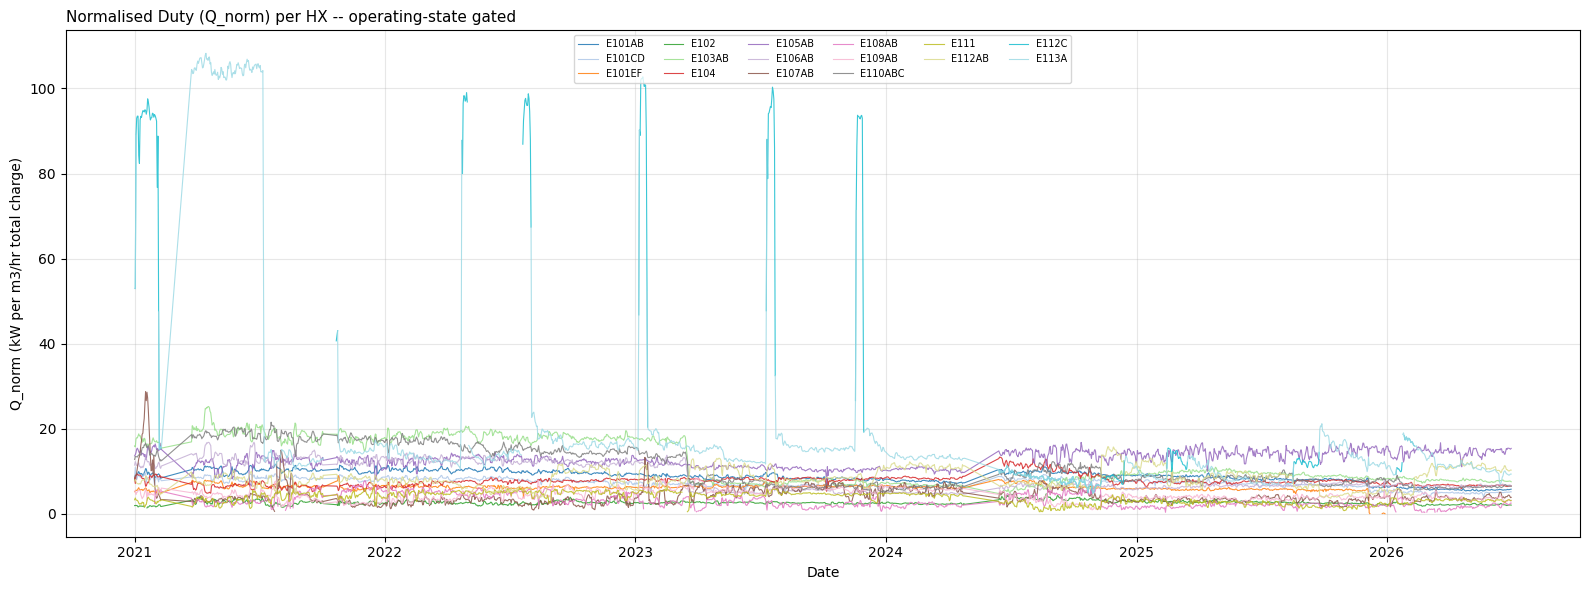

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
colors = plt.cm.tab20(np.linspace(0, 1, len(HX_CONFIG)))
for (hx, _), color in zip(HX_CONFIG.items(), colors):
    ax.plot(Q_norm_df.index, Q_norm_df[hx], label=hx, color=color, linewidth=0.8, alpha=0.85)
ax.set_ylabel('Q_norm (kW per m3/hr total charge)')
ax.set_xlabel('Date')
ax.set_title('Normalised Duty (Q_norm) per HX -- operating-state gated', fontsize=11, loc='left')
ax.legend(fontsize=7, ncol=6, loc='upper center')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2b_Q_norm_all_hx.png'), bbox_inches='tight')
plt.show()

---
## 3. Campaign (Run) Segmentation

A "campaign" is a continuous stretch where a given piece of equipment is
on-duty between clean events. Boundaries come from three sources:

1. **TAM** (plant-wide shutdown): total charge < 200 m3/hr for >= 3 days
2. **Shell/state transition** (from `2a`): the operating-state code for this
   HX changes (e.g. E113A goes SUBSTITUTED -> NORMAL) -- this is what lets
   E113A and E112C be scored as separate pieces of equipment even though they
   share one crude-side tag pair
3. **Q jump**: smoothed Q_norm jumps up >= 40 W/(m2*K)-equivalent while the
   plant is running and outside a TAM window (classic shell-switch/clean
   signature for HX with no explicit state tracking in `2a`)

In [7]:
TAM_FLOW_THRESH = 200.0
TAM_MIN_DAYS = 3
SWITCH_JUMP_FRAC = 0.15    # smoothed jump, as a fraction of the HX's own median Q_norm
SWITCH_SMOOTH_WIN = 3
EVENT_DEDUP_DAYS = 7

total_flow = df[TOTAL_CHARGE_TAG]
is_shutdown = total_flow < TAM_FLOW_THRESH

tam_dates = []
in_period, period_start = False, None
for date, shut in is_shutdown.items():
    if shut and not in_period:
        in_period, period_start = True, date
    elif not shut and in_period:
        in_period = False
        if (date - period_start).days >= TAM_MIN_DAYS:
            tam_dates.append(date)

print(f'TAM events (plant restart dates): {len(tam_dates)}')
print('(0 is expected here -- TAM/shutdown windows were already removed upstream in '
      '01_data_cleaning.ipynb; this check exists in case a future data refresh '
      'is fed in without that step)')
for d in tam_dates:
    print(f'  {d.date()}')

TAM events (plant restart dates): 0
(0 is expected here -- TAM/shutdown windows were already removed upstream in 01_data_cleaning.ipynb; this check exists in case a future data refresh is fed in without that step)


In [8]:
def campaign_boundaries_for_hx(hx):
    """Return sorted list of campaign-start dates for one HX."""
    starts = set(tam_dates)

    if hx in state.columns:
        s = state[hx]
        changed = s != s.shift(1)
        # a transition INTO an active state (NORMAL/SUBSTITUTE_ACTIVE) starts a new campaign
        into_active = changed & s.isin(VALID_STATES)
        starts.update(s.index[into_active])

    q = Q_norm_df[hx]
    q_smooth = q.rolling(SWITCH_SMOOTH_WIN, min_periods=2).mean()
    jump = q_smooth.diff()
    jump_thresh = SWITCH_JUMP_FRAC * q.median()   # scale threshold to this HX's own duty size
    plant_running = total_flow > TAM_FLOW_THRESH
    candidates = jump[(jump > jump_thresh) & plant_running].index
    starts.update(candidates)

    starts = sorted(d for d in starts if pd.notna(d))
    deduped, last = [], None
    for d in starts:
        if last is None or (d - last).days > EVENT_DEDUP_DAYS:
            deduped.append(d)
            last = d
    return deduped

campaign_starts = {hx: campaign_boundaries_for_hx(hx) for hx in HX_CONFIG}
print('Campaigns detected per HX:')
for hx, starts in campaign_starts.items():
    print(f'  {hx:10s}: {len(starts)} boundary event(s)')

Campaigns detected per HX:
  E101AB    : 1 boundary event(s)
  E101CD    : 1 boundary event(s)
  E101EF    : 2 boundary event(s)
  E102      : 4 boundary event(s)
  E103AB    : 3 boundary event(s)
  E104      : 2 boundary event(s)
  E105AB    : 1 boundary event(s)
  E106AB    : 3 boundary event(s)
  E107AB    : 33 boundary event(s)
  E108AB    : 42 boundary event(s)
  E109AB    : 16 boundary event(s)
  E110ABC   : 2 boundary event(s)
  E111      : 11 boundary event(s)
  E112AB    : 10 boundary event(s)
  E112C     : 14 boundary event(s)
  E113A     : 19 boundary event(s)


---
## 4. Fouling-Rate Ranking -- Initiation vs After-Initiation Phase

**Aligned with the framework already used in `02_feature_engineering.ipynb`**
(`CLEAN_WINDOW_DAYS` / `FOULING_LAG_DAYS`) -- fitting a trend over a
campaign's *entire* length mixes two physically different regimes:

- **Initiation phase** (first `FOULING_LAG_DAYS` days of a campaign): the
  shell just came clean online/came back from a swap -- Q_norm here is
  noisy transient (flow/temperature re-stabilising), not a fouling trend.
  It also serves as the "how good was this clean" baseline.
- **After-initiation phase** (everything after that): the regime where a
  declining Q_norm actually reflects fouling building up.

Fitting the whole campaign (as the previous version of this notebook did)
lets the initiation-phase noise bias the slope and, downstream in `2c`,
under/over-counted "cleaning" events and unreliable time-to-threshold
projections. Fix: **skip the initiation window before fitting**, and use
`scipy.stats.linregress` so **R²** comes along with the slope -- a low R²
means "don't trust this HX's projected fouling rate," which `2c` now
surfaces directly instead of presenting every projection with equal
confidence.

In [9]:
MIN_CAMPAIGN_DAYS = 10     # minimum length for a campaign to be considered at all
FOULING_LAG_DAYS = 15      # initiation-phase length -- matches 02_feature_engineering.ipynb
MIN_REGRESSION_PTS = 14    # after-initiation points required to trust a fitted slope

def campaigns_as_ranges(hx):
    starts = campaign_starts[hx]
    idx = Q_norm_df.index
    bounds = starts + [idx.max() + pd.Timedelta(days=1)]
    ranges = []
    prev = idx.min()
    for b in bounds:
        ranges.append((prev, b))
        prev = b
    return ranges

fouling_rows = []
for hx in HX_CONFIG:
    slopes, pct_drops, r2s = [], [], []
    for c_start, c_end in campaigns_as_ranges(hx):
        if (c_end - c_start).days < MIN_CAMPAIGN_DAYS:
            continue

        foul_start = c_start + pd.Timedelta(days=FOULING_LAG_DAYS)   # skip initiation phase
        s = Q_norm_df.loc[foul_start:c_end, hx].dropna()
        if len(s) < MIN_REGRESSION_PTS:
            continue

        x = (s.index - foul_start).days.values.astype(float)
        slope, intercept, r_value, p_value, _ = stats.linregress(x, s.values)
        if abs(intercept) > 1e-6:
            slopes.append(slope)
            pct_drops.append(slope / abs(intercept) * 30 * 100)
            r2s.append(r_value ** 2)

    if slopes:
        fouling_rows.append({
            'HX': hx,
            'group': 'CPHT-1' if hx in CPHT_1_HX else 'CPHT-2',
            'n_campaigns': len(slopes),
            'median_Q_slope': np.median(slopes),
            'median_pct_drop_per_30d': np.median(pct_drops),
            'median_R2': np.median(r2s),
            'mean_Q_norm': Q_norm_df[hx].mean(),
        })

fouling_rank = pd.DataFrame(fouling_rows).sort_values('median_Q_slope').reset_index(drop=True)
print(f'Fouling-rate ranking -- after-initiation phase only ({FOULING_LAG_DAYS}d lag skipped per '
      'campaign); most negative slope = fouls fastest; median_R2 = trend reliability:')
fouling_rank.round(5)

Fouling-rate ranking -- after-initiation phase only (15d lag skipped per campaign); most negative slope = fouls fastest; median_R2 = trend reliability:


,HX,group,n_campaigns,median_Q_slope,median_pct_drop_per_30d,median_R2,mean_Q_norm
0,E113A,CPHT-2,11,-0.02716,-5.30501,0.39006,19.16263
1,E112C,CPHT-2,4,-0.02188,-5.34403,0.26485,30.07522
2,E107AB,CPHT-2,17,-0.01311,-6.52402,0.17924,4.21886
3,E106AB,CPHT-2,3,-0.00427,-1.05169,0.28300,8.60950
4,E109AB,CPHT-2,13,-0.00414,-3.43146,0.10007,4.44699
5,E112AB,CPHT-2,10,-0.00327,-1.07919,0.08341,8.35887
6,E101AB,CPHT-1,1,-0.00192,-0.53200,0.60578,8.85474
7,E111,CPHT-2,10,-0.00173,-1.07388,0.01284,3.70345
8,E104,CPHT-2,2,-0.00165,-0.36131,0.55094,7.75173
9,E101CD,CPHT-1,1,-0.00134,-0.46708,0.47919,7.24510


---
## 4b. Q_duty Ranking (Mean Q_norm per HX)

Ranks HX by their mean normalised duty (`mean_Q_norm`) over the whole
history -- a size/loading ranking, independent of fouling rate. Useful to
sanity-check which HX actually carry the most duty per unit of crude
throughput.

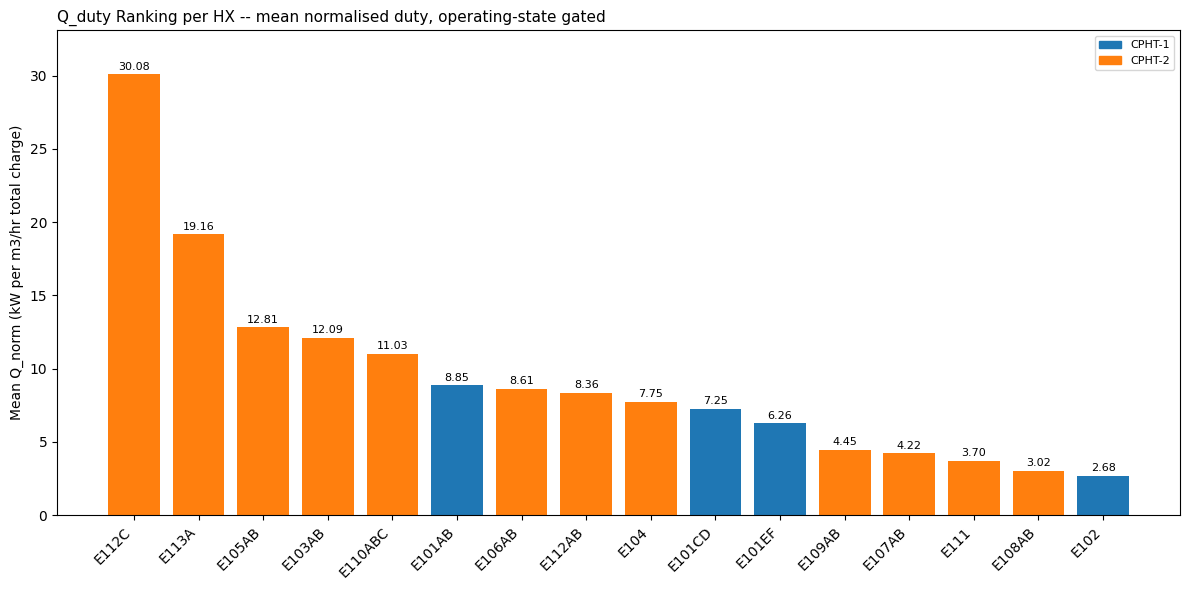

In [10]:
qr = fouling_rank.sort_values('mean_Q_norm', ascending=False)
group_colors = {'CPHT-1': 'tab:blue', 'CPHT-2': 'tab:orange'}
colors = [group_colors[g] for g in qr['group']]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(qr['HX'], qr['mean_Q_norm'], color=colors)
ax.bar_label(bars, fmt='%.2f', fontsize=8, padding=2)
ax.set_ylabel('Mean Q_norm (kW per m3/hr total charge)')
ax.set_title('Q_duty Ranking per HX -- mean normalised duty, operating-state gated', fontsize=11, loc='left')
ax.set_xticks(range(len(qr)))
ax.set_xticklabels(qr['HX'], rotation=45, ha='right')
ax.margins(y=0.1)
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2b_Q_duty_ranking.png'), bbox_inches='tight')
plt.show()

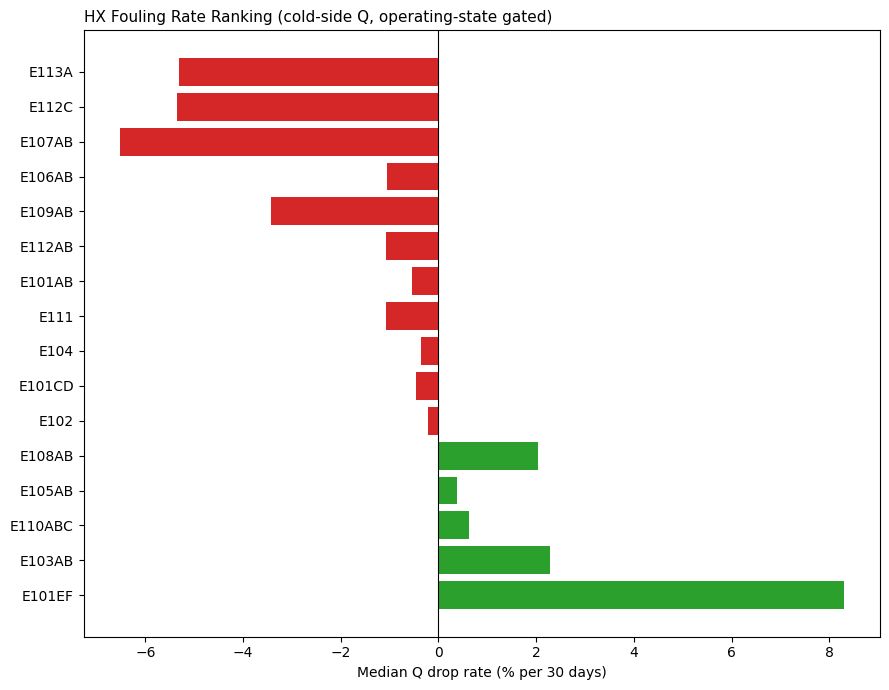

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
fr = fouling_rank.dropna(subset=['median_pct_drop_per_30d'])
colors = ['tab:red' if v < 0 else 'tab:green' for v in fr['median_pct_drop_per_30d']]
ax.barh(fr['HX'], fr['median_pct_drop_per_30d'], color=colors)
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Median Q drop rate (% per 30 days)')
ax.set_title('HX Fouling Rate Ranking (cold-side Q, operating-state gated)', fontsize=11, loc='left')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '2b_fouling_rate_ranking.png'), bbox_inches='tight')
plt.show()

---
## 5. Current Fouling Status (Q Drop From Campaign Baseline)

Baseline = 90th percentile of the current campaign's **initiation phase**
(first `FOULING_LAG_DAYS` days -- same window used for the fouling-rate fit
in Section 4, so "how clean was this clean" is defined consistently
everywhere in this notebook). Falls back to the first 10% of the campaign
if the initiation window has too few points (short/recent campaign).
Current = latest available Q_norm.

In [12]:
last_date = Q_norm_df.index.max()
status_rows = []

for hx in HX_CONFIG:
    ranges = campaigns_as_ranges(hx)
    c_start, c_end = ranges[-1]
    s = Q_norm_df.loc[c_start:c_end, hx].dropna()
    if len(s) < MIN_CAMPAIGN_DAYS:
        continue

    init_window = s[s.index < c_start + pd.Timedelta(days=FOULING_LAG_DAYS)]
    baseline_pts = init_window if len(init_window) >= 5 else s.iloc[:max(5, len(s) // 10)]
    baseline = np.percentile(baseline_pts.values, 90)
    current = s.values[-1]
    drop_frac = (baseline - current) / abs(baseline) if abs(baseline) > 1e-6 else np.nan

    currently_active = bool(state[hx].iloc[-1] in VALID_STATES) if hx in state.columns else True

    status_rows.append({
        'HX': hx,
        'campaign_start': c_start.date(),
        'days_in_campaign': (last_date - c_start).days,
        'baseline_Q_norm': round(baseline, 4),
        'current_Q_norm': round(current, 4),
        'Q_drop_pct': round(drop_frac * 100, 1) if pd.notna(drop_frac) else np.nan,
        'currently_active': currently_active,
    })

fouling_status = pd.DataFrame(status_rows).sort_values('Q_drop_pct', ascending=False).reset_index(drop=True)
print('NOTE: currently_active=False means the last Q_norm reading predates the HX going '
      'OFF/SUBSTITUTED -- its Q_drop_pct reflects the moment it was taken out of service, '
      'NOT an ongoing fouling trend. Only currently_active=True rows are live fouling status.')
fouling_status

NOTE: currently_active=False means the last Q_norm reading predates the HX going OFF/SUBSTITUTED -- its Q_drop_pct reflects the moment it was taken out of service, NOT an ongoing fouling trend. Only currently_active=True rows are live fouling status.


,HX,campaign_start,days_in_campaign,baseline_Q_norm,current_Q_norm,Q_drop_pct,currently_active
0,E101EF,2021-03-26,1923,7.7923,0.0514,99.3,False
1,E103AB,2021-04-14,1904,25.1485,7.5651,69.9,True
2,E110ABC,2021-03-25,1924,18.6308,6.4916,65.2,True
3,E106AB,2021-06-19,1838,16.4815,6.6289,59.8,True
4,E104,2024-06-14,747,13.2992,6.5906,50.4,True
5,E102,2024-06-14,747,4.1197,2.0650,49.9,True
6,E113A,2026-01-24,158,18.5732,9.3602,49.6,True
7,E101CD,2021-01-01,2007,9.2046,5.1978,43.5,True
8,E101AB,2021-01-01,2007,9.6912,5.8118,40.0,True
9,E109AB,2024-11-11,597,4.5486,3.0579,32.8,True


---
## 6. Export

Two artifacts for `2c`/`2d`:
- `Feature_Q.csv` -- Q_norm per HX (operating-state gated), daily
- `Fouling_Rate_Ranking.csv` -- one row per HX: fouling rate + current status

In [13]:
DATA_DIR = r'C:\Desktop\Bangchak Internship 2026\Data'

Q_norm_df.to_csv(DATA_DIR + r'\Feature_Q.csv')

fouling_summary = fouling_rank.merge(
    fouling_status[['HX', 'Q_drop_pct', 'days_in_campaign', 'currently_active']], on='HX', how='left')
fouling_summary.to_csv(DATA_DIR + r'\Fouling_Rate_Ranking.csv', index=False)

print('Wrote Feature_Q.csv', Q_norm_df.shape)
print('Wrote Fouling_Rate_Ranking.csv', fouling_summary.shape)
fouling_summary.round(4)

Wrote Feature_Q.csv (1898, 16)
Wrote Fouling_Rate_Ranking.csv (16, 10)


,HX,group,n_campaigns,median_Q_slope,median_pct_drop_per_30d,median_R2,mean_Q_norm,Q_drop_pct,days_in_campaign,currently_active
0,E113A,CPHT-2,11,-0.0272,-5.3050,0.3901,19.1626,49.6,158,True
1,E112C,CPHT-2,4,-0.0219,-5.3440,0.2649,30.0752,11.0,156,False
2,E107AB,CPHT-2,17,-0.0131,-6.5240,0.1792,4.2189,19.1,110,True
3,E106AB,CPHT-2,3,-0.0043,-1.0517,0.2830,8.6095,59.8,1838,True
4,E109AB,CPHT-2,13,-0.0041,-3.4315,0.1001,4.4470,32.8,597,True
5,E112AB,CPHT-2,10,-0.0033,-1.0792,0.0834,8.3589,-10.7,141,True
6,E101AB,CPHT-1,1,-0.0019,-0.5320,0.6058,8.8547,40.0,2007,True
7,E111,CPHT-2,10,-0.0017,-1.0739,0.0128,3.7035,19.0,566,True
8,E104,CPHT-2,2,-0.0016,-0.3613,0.5509,7.7517,50.4,747,True
9,E101CD,CPHT-1,1,-0.0013,-0.4671,0.4792,7.2451,43.5,2007,True
